## Simple Linear Regression

In [5]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
data = {'X': [3,4,3,5,2], 'Y': [8,9,7,10,6]}
df = pd.DataFrame(data)
X = df.drop('Y', axis=1)
y = df['Y']
# x_train,x_test,y_train,y_test= train_test_split(X,y,test_size=0.25, random_state=42)
model = LinearRegression()
model.fit(X,y)
print(model.intercept_)
print(model.coef_)
print(model.predict([[6]]))


3.4230769230769225
[1.34615385]
[11.5]


/home/user/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [197]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings as warn, seaborn as sns
warn.filterwarnings('ignore')
%matplotlib inline

In [198]:
df = pd.read_csv('height-weight.csv')


In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [4]:
df.isna().sum()

Weight    0
Height    0
dtype: int64

In [5]:
df.duplicated().sum()

1

In [6]:
df.drop_duplicates(keep = 'first', inplace = True)

In [7]:
df.duplicated().sum()

0

<Axes: >

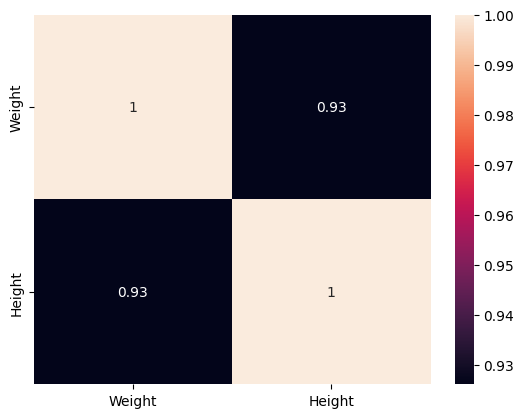

In [8]:
sns.heatmap(df.corr(), annot = True)

In [9]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
std_scaler = StandardScaler()

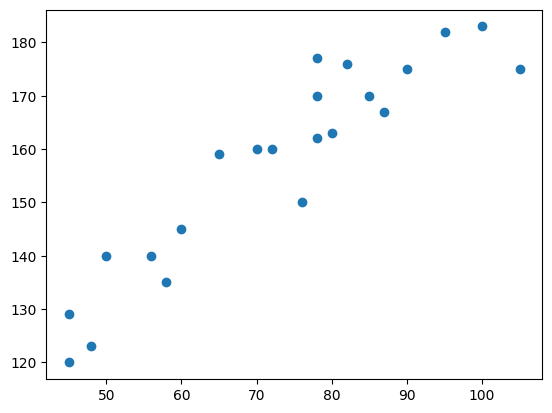

In [13]:
plt.scatter(df['Weight'], df['Height'])
# plt.plot(df['Weight'],df['Height'],'r')

In [14]:
df['Weight'] = std_scaler.fit_transform(df[['Weight']])

In [15]:
df.head()

,Weight,Height
0,-1.613778,120
1,-0.860857,135
2,-1.440027,123
3,-0.745023,145
4,-0.165853,160


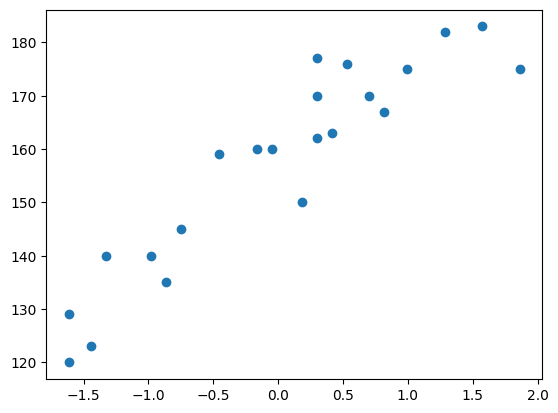

In [16]:
plt.scatter(df['Weight'], df['Height'])

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x = df[['Weight']]
y = df['Height']

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.20, random_state = 42)

In [20]:
x_train.shape

(17, 1)

In [21]:
x_test.shape

(5, 1)

In [22]:
y_train.shape

(17,)

In [23]:
y_test.shape

(5,)

In [24]:
df.shape

(22, 2)

In [25]:
df.size

44

In [26]:
from sklearn.linear_model import LinearRegression
linear_regressor = LinearRegression()
linear_regressor.fit(x_train,y_train)

LinearRegression()

In [27]:
y_pred = linear_regressor.predict(x_test)

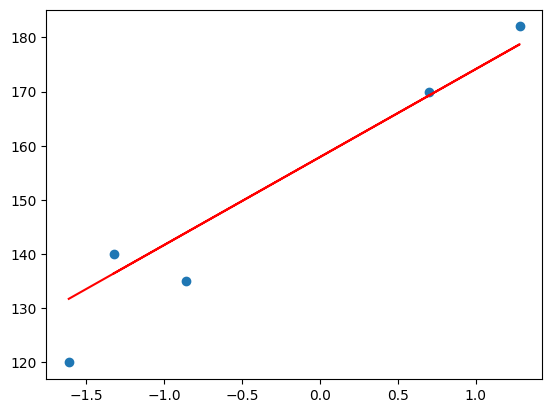

In [28]:
plt.scatter(x_test,y_test)
plt.plot(x_test, y_pred, 'r')

In [30]:
linear_regressor.intercept_ #c 

157.9164852752881

In [31]:
linear_regressor.coef_ #m

array([16.21945931])

In [32]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [33]:
r2  = r2_score(y_test,y_pred)

In [34]:
adjusted_r2_score = 1 - ((1-r2)*(len(x_test)-1)/(len(x_test)-x_test.shape[1]-1))

In [35]:
adjusted_r2_score

0.8781056659699931

In [36]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

In [37]:
mae

5.645752979414948

In [38]:
mse

48.401802156635156

In [39]:
rmse

6.957140372066324

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [41]:
## Read the dataset
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

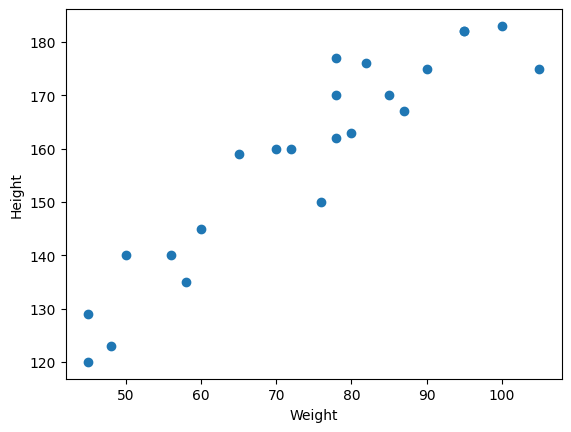

In [42]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [43]:
## divide our dataset into independent and dependent edatures
X=df[['Weight']] ##independent feature
y=df['Height'] ##dependent feature

In [44]:
## Train test split
from sklearn.model_selection import train_test_split

In [45]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [46]:
X.shape

(23, 1)

In [47]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [48]:
## standardize the dataset Train independent data
from sklearn.preprocessing import StandardScaler

In [49]:
scaler=StandardScaler()

In [50]:
X_train.head()

,Weight
12,105
1,58
13,100
5,78
2,48


In [54]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

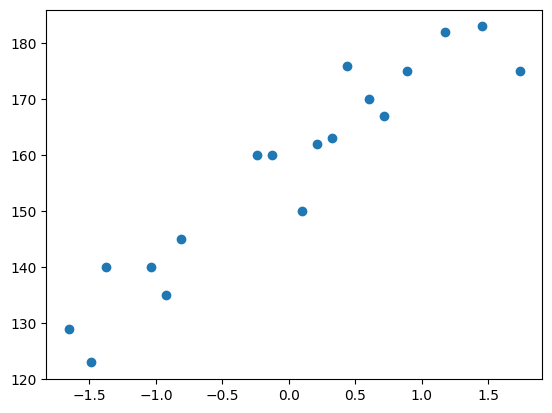

In [55]:
plt.scatter(X_train,y_train)

In [56]:
## Train the Simple Linear Regression Model
from sklearn.linear_model import LinearRegression

In [57]:
regressor=LinearRegression()

In [58]:
regressor.fit(X_train,y_train)

LinearRegression()

In [59]:
print("The slope or coefficient of weight is ",regressor.coef_)
print("Intercept:",regressor.intercept_)

The slope or coefficient of weight is  [17.03440872]
Intercept: 157.5


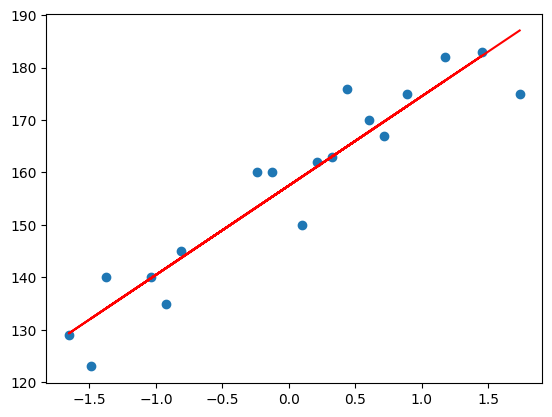

In [60]:

plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),'r')

### prediction of train data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_train =157.5 + 17.03(X_train)
          
### prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =157.5 + 17.03(X_test)

In [61]:
y_pred_test=regressor.predict(X_test)

In [67]:
regressor.coef_

array([17.03440872])

In [71]:
regressor.intercept_

157.5

In [62]:
y_pred_test,y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

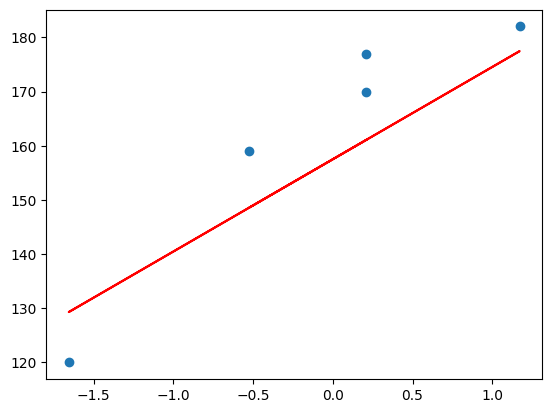

In [63]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regressor.predict(X_test),'r')

## Performance Metrics

## MSE,MAE,RMSE
## R square and adjusted R square

In [64]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [65]:
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051658
9.822657814519232
10.477400726827078


## R square
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [66]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred_test)

In [135]:
score

0.776986986042344

## Adjusted R Square

**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [136]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231252

In [137]:
regressor

LinearRegression()

In [138]:
## new data point weight is 80

scaled_weight=scaler.transform([[80]])
scaled_weight

array([[0.32350772]])

In [139]:
scaled_weight[0]

array([0.32350772])

In [140]:
print("The height prediction for weight 80 kg is :",regressor.predict([scaled_weight[0]]))

The height prediction for weight 80 kg is : [163.01076266]


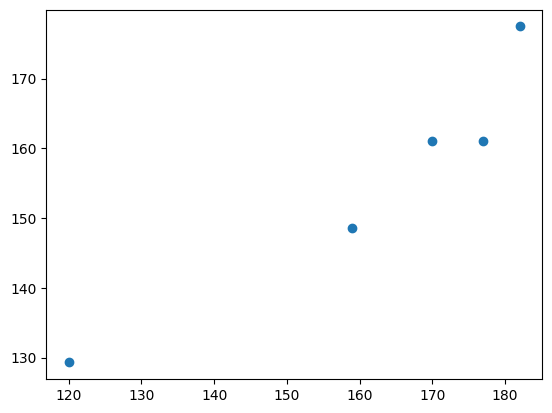

In [141]:
## Assumptions
## plot a scatter plot for the prediction
plt.scatter(y_test,y_pred_test)

In [142]:
## Residuals
residuals=y_test-y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Density'>

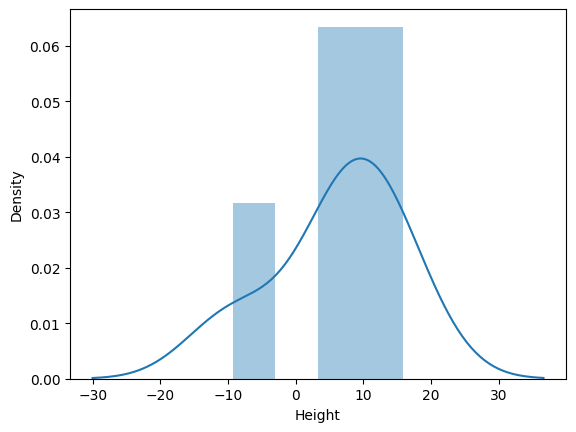

In [143]:
## plot this residuals
import seaborn as sns
sns.distplot(residuals,kde=True)

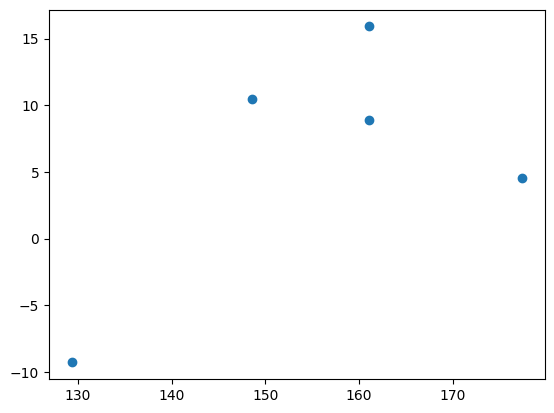

In [144]:
## Scatter plot with respect to prediction and residuals
## uniform distribution
plt.scatter(y_pred_test,residuals)

In [72]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

In [158]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.datasets import fetch_california_housing

In [169]:
df = pd.read_csv('height-weight.csv')
calf  = fetch_california_housing()
df = pd.DataFrame(calf.data, columns = calf.feature_names)
df['Price'] = calf.target

In [170]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [171]:
df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [172]:
df.duplicated().sum()

0

In [173]:
df = df.drop_duplicates()

In [174]:
# plt.scatter(df['Weight'], df['Height'])

In [87]:
from sklearn.preprocessing import StandardScaler

In [88]:
std_scaler = StandardScaler()

In [94]:
df[['Weight']]

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [176]:
# X = df[['Weight']]
# y = df['Height']
X = df.drop('Price',axis = 1)
y = df['Price']

In [177]:
X_train,  X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=42)

In [178]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
8158,4.2143,37.0,5.288235,0.973529,860.0,2.529412,33.81,-118.12
18368,5.3468,42.0,6.364322,1.087940,957.0,2.404523,37.16,-121.98
19197,3.9191,36.0,6.110063,1.059748,711.0,2.235849,38.45,-122.69
3746,6.3703,32.0,6.000000,0.990196,1159.0,2.272549,34.16,-118.41
13073,2.3684,17.0,4.795858,1.035503,706.0,2.088757,38.57,-121.33
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [179]:
y_train

8158     2.285
18368    2.799
19197    1.830
3746     4.658
13073    1.500
         ...  
11284    2.292
11964    0.978
5390     2.221
860      2.835
15795    3.250
Name: Price, Length: 15480, dtype: float64

In [180]:
X_train = std_scaler.fit_transform(X_train)

In [181]:
X_test = std_scaler.transform(X_test)

In [182]:
model = LinearRegression()

In [183]:
model.fit(X_train,y_train)

LinearRegression()

In [184]:
y_pred = model.predict(X_test)

In [185]:
mean_absolute_error(y_test,y_pred)

0.5296964012919462

In [186]:
mean_squared_error(y_test,y_pred)

0.5411287478470689

In [189]:
r2_score(y_test,y_pred)

0.5910509795491351

In [190]:
def adjusted_r2_score(y_test,y_pred):
    return 1 - (((1-r2_score(y_test,y_pred))*(len(X_test)-1))/(len(X_test)-X_test.shape[1]-1))

In [191]:
adjusted_r2_score(y_test,y_pred)

0.590415842262471

In [192]:
model.coef_

array([ 0.85210815,  0.12065533, -0.30210555,  0.34860575, -0.00164465,
       -0.04116356, -0.89314697, -0.86784046])

In [193]:
model.intercept_


2.0703489205426377

In [196]:
# plt.scatter(X_test,y_pred)
# plt.plot(X_test, y_pred, c = 'r')

In [124]:
df.describe()

,Weight,Height
count,22.000000,22.000000
mean,72.863636,157.318182
std,17.672404,19.263551
min,45.000000,120.000000
25%,58.500000,141.250000
50%,77.000000,161.000000
75%,84.250000,173.750000
max,105.000000,183.000000


In [125]:
df.shape

(22, 2)

In [202]:
df['cat'] = ['A','B', 'C', 'A', 'B', 'C', 'A', 'B', 'C', 'A','B', 'C', 'A', 'B', 'C', 'A', 'B', 'C', 'A', 'B', 'C', 'A', 'B']

In [127]:
df.groupby('cat').mean()

,Weight,Height
cat,,
A,71.500000,156.000000
B,70.714286,157.714286
C,76.571429,158.428571


In [128]:
df.groupby('cat').std()

,Weight,Height
cat,,
A,18.761663,19.942775
B,16.121562,18.847761
C,19.965446,21.808692


In [129]:
df.head()

,Weight,Height,cat
0,45,120,A
1,58,135,B
2,48,123,C
3,60,145,A
4,70,160,B


In [147]:
df.groupby('cat').sum().sort_values(by='Height').head(1)

,Weight,Height
cat,,
B,495,1104


In [148]:
df.groupby('cat').sum().sort_values(by='Height', ascending=False).head(1)

,Weight,Height
cat,,
A,572,1248


In [149]:
df.groupby('cat').mean()

,Weight,Height
cat,,
A,71.500000,156.000000
B,70.714286,157.714286
C,76.571429,158.428571


In [150]:
df.groupby('cat').std()

,Weight,Height
cat,,
A,18.761663,19.942775
B,16.121562,18.847761
C,19.965446,21.808692


In [203]:
df.loc[df['Height'].idxmax()]

Weight    100
Height    183
cat         B
Name: 13, dtype: object

In [204]:
df.loc[df['Height'].idxmin()]

Weight     45
Height    120
cat         A
Name: 0, dtype: object

In [205]:
df['Height'].mean()

158.3913043478261

In [206]:
df['Height'].std()

19.51162620880825

In [152]:
arr = np.random.randint(1,100,(3,3))

In [153]:
arr.T

array([[81, 25, 60],
       [79, 20,  5],
       [74, 83, 40]])

In [154]:
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [155]:
arr.T*np.eye(3)

array([[81.,  0.,  0.],
       [ 0., 20.,  0.],
       [ 0.,  0., 40.]])

In [157]:
np.diag(arr.flatten())

array([[81,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 79,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 74,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 25,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 20,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 83,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 60,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  5,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 40]])

In [ ]:
plt.bar(